In [14]:
import sys
print(sys.executable)

!pip show gym-electric-motor


d:\Github\Machine-Learning-Studies\conda-env\python.exe
Name: gym_electric_motor
Version: 3.0.2
Summary: A Farama Gymnasium environment for electric motor control.
Home-page: 
Author: Arne Traue, Gerrit Book, Praneeth Balakrishna, Pascal Peters, Pramod Manjunatha, Darius Jakobeit, Felix Book, Max Schenke, Wilhelm Kirchgässner, Oliver Wallscheid, Barnabas Haucke-Korber, Stefan Arndt, Marius Köhler, Ranil Thomas
Author-email: 
License: 
Location: d:\github\machine-learning-studies\conda-env\lib\site-packages
Requires: gymnasium, matplotlib, numpy, pathspec, pytest, pytest-cov, scipy
Required-by: 


In [39]:
import gymnasium as gym
import gym_electric_motor

env_ids = [env.id for env in gym.envs.registry.values()]
print("Registered envs:")
print(env_ids)


Registered envs:
['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v1', 'CliffWalkingSlippery-v1', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoi

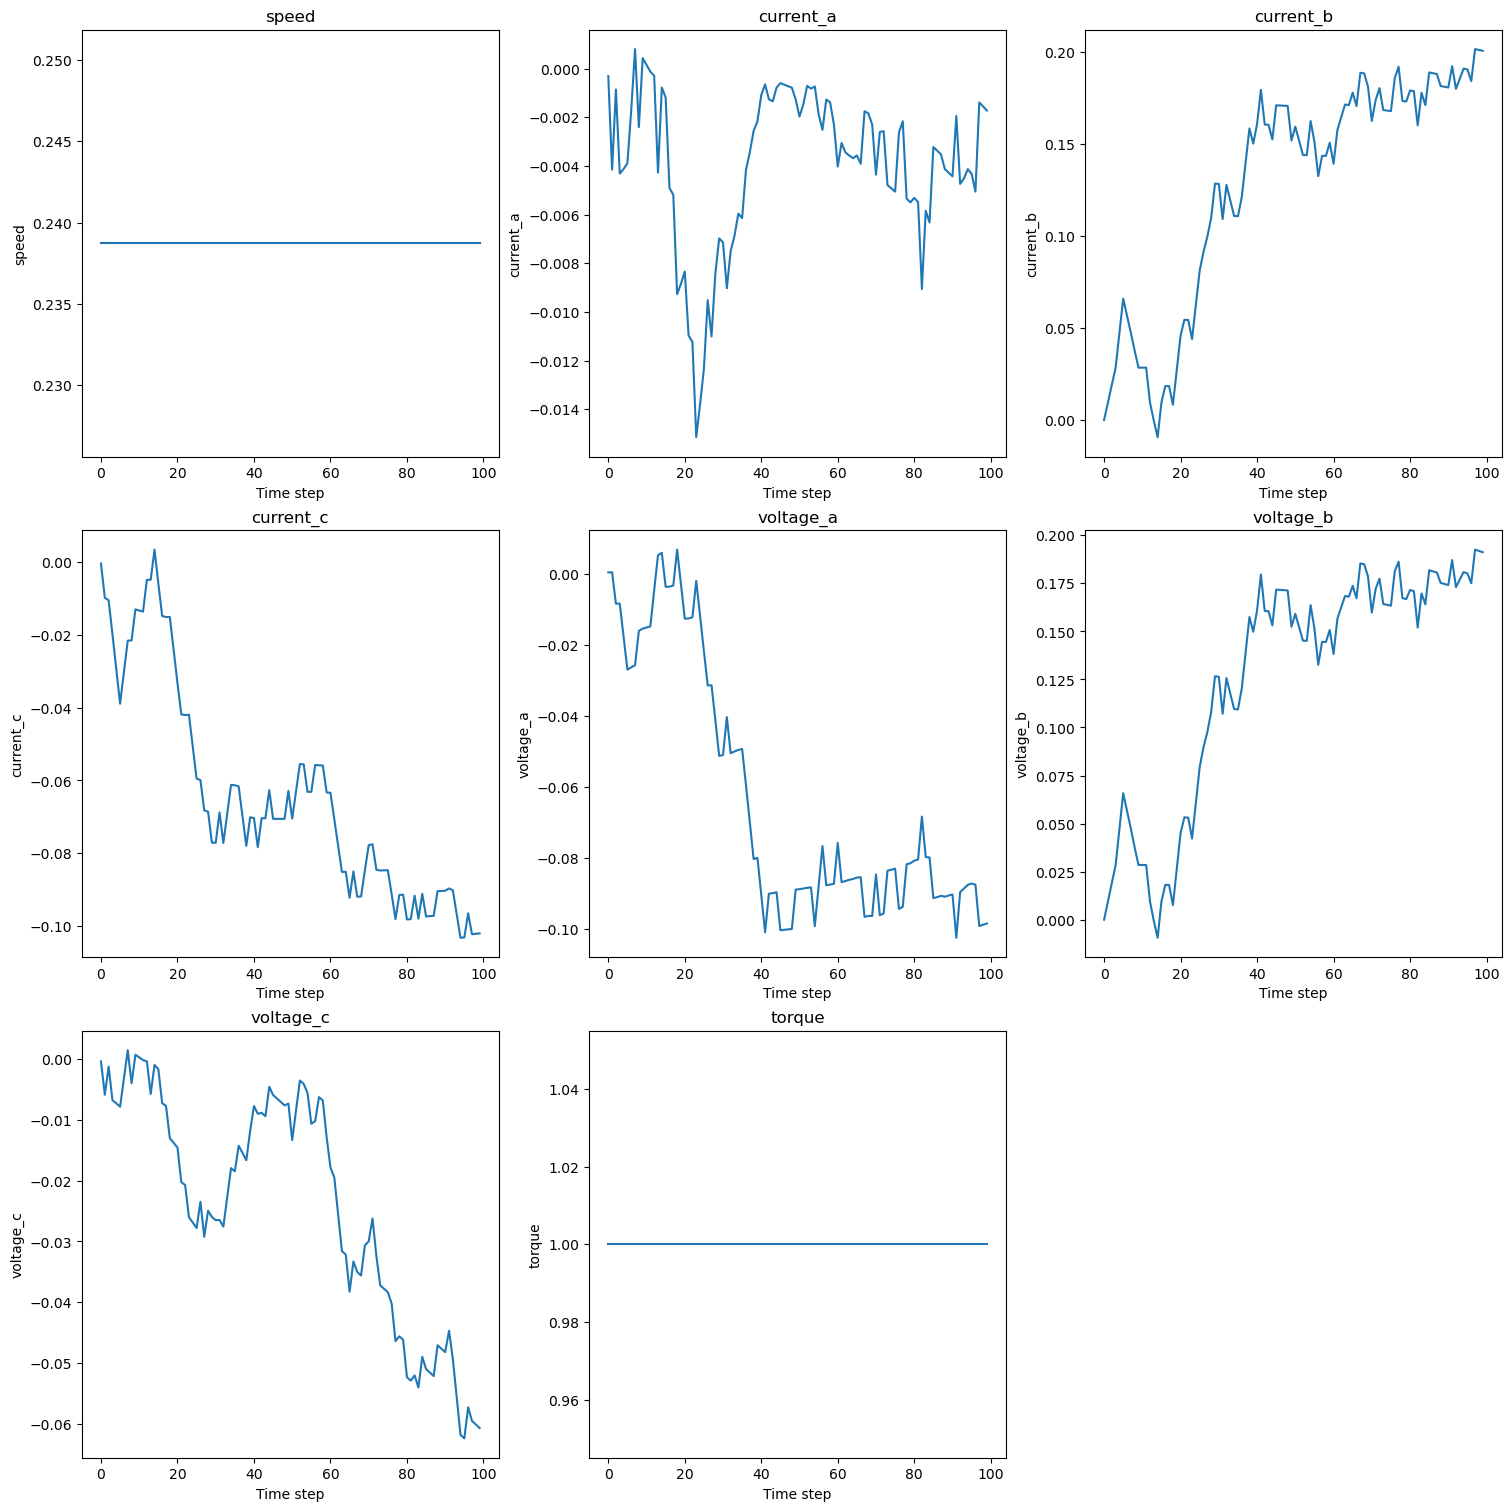

In [47]:
import gymnasium as gym
import gym_electric_motor
import matplotlib.pyplot as plt

env = gym.make("Finite-CC-PMSM-v0")
obs, info = env.reset()

data = {
    "speed": [],
    "current_a": [],
    "current_b": [],
    "current_c": [],
    "voltage_a": [],
    "voltage_b": [],
    "voltage_c": [],
    "torque": [],
}

done = False
step = 0
max_steps = 100

while not done and step < max_steps:
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    
    data["speed"].append(obs[0][0])
    data["current_a"].append(obs[0][1])
    data["current_b"].append(obs[0][2])
    data["current_c"].append(obs[0][3])
    data["voltage_a"].append(obs[0][4])
    data["voltage_b"].append(obs[0][5])
    data["voltage_c"].append(obs[0][6])
    data["torque"].append(obs[0][13])
    
    step += 1

# Vẽ chart

keys = list(data.keys())
num_plots = len(keys)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows), constrained_layout=True)

for i, key in enumerate(keys):
    r = i // cols
    c = i % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.plot(range(len(data[key])), data[key])
    ax.set_title(key)
    ax.set_xlabel("Time step")
    ax.set_ylabel(key)

# Ẩn các subplot thừa nếu có
for j in range(num_plots, rows*cols):
    r = j // cols
    c = j % cols
    ax = axs[r, c] if rows > 1 else axs[c]
    ax.axis('off')

plt.show()


In [45]:
print(obs)
print(type(obs))
print(len(obs) if hasattr(obs, '__len__') else "No length")

(array([ 2.38732415e-01, -3.05093239e-04, -2.00632955e-06, -3.56204987e-04,
        3.58211317e-04, -2.00632955e-06, -4.12468445e-04,  1.40000000e+00,
        1.40000000e+00,  1.40000000e+00,  0.00000000e+00,  0.00000000e+00,
        9.54929659e-04,  1.00000000e+00]), array([-0.318329  ,  0.23246475]))
<class 'tuple'>
2
